# Пайплайн аугментации

Ноутбук последовательно:
1. Разбивает данные на **train/test** (80/20, стратифицированно)
2. Аугментирует **только train** через 3 этапа
3. Оценивает baseline-классификаторы **на test**

**Этапы аугментации:**
1. LLM-генерация (< 15 → 15)
2. Парафраз через LLM (< 35 → 35)
3. Обратный перевод (< 50 → 50)

**Классификация (baseline):**
- Linear SVM (TF-IDF)
- Logistic Regression (TF-IDF)
- Multinomial Naive Bayes (TF-IDF)
- rubert-tiny2 (fine-tuning)

___
## Подготовка окружения (Запуск в Colab)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path

REPO_URL = 'https://github.com/KVTur23/Mifi_VKR.git'
REPO_BRANCH = 're-augmentation'
REPO_DIR = Path('/content/VKR')
PROJECT_ROOT = REPO_DIR / 'code'

DRIVE_ROOT = Path('/content/drive/MyDrive/VKR')
DRIVE_DATA = DRIVE_ROOT / 'Data'
DRIVE_RESULTS = DRIVE_ROOT / 'results'
DRIVE_LOGS = DRIVE_ROOT / 'logs'


In [3]:
import shutil
import subprocess

if (REPO_DIR / '.git').exists():
    print('Репо уже клонирован — обновляю из origin')
    subprocess.run(['git', '-C', str(REPO_DIR), 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', str(REPO_DIR), 'checkout', '-B', REPO_BRANCH, f'origin/{REPO_BRANCH}'], check=True)
else:
    print(f'Клонирую {REPO_URL} в {REPO_DIR}')
    subprocess.run(['git', 'clone', '-b', REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)

def link_to_drive(name, drive_path):
    local_path = PROJECT_ROOT / name
    drive_path.parent.mkdir(parents=True, exist_ok=True)

    drive_missing_or_empty = not drive_path.exists() or not any(drive_path.iterdir())
    if drive_missing_or_empty:
        if local_path.exists() and not local_path.is_symlink():
            if drive_path.exists():
                shutil.rmtree(drive_path)
            shutil.copytree(local_path, drive_path)
        else:
            drive_path.mkdir(parents=True, exist_ok=True)

    if local_path.is_symlink() or local_path.is_file():
        local_path.unlink()
    elif local_path.exists():
        shutil.rmtree(local_path)

    local_path.symlink_to(drive_path, target_is_directory=True)
    print(f'{name}: {local_path} -> {drive_path}')

link_to_drive('Data', DRIVE_DATA)
link_to_drive('results', DRIVE_RESULTS)
link_to_drive('logs', DRIVE_LOGS)

commit = subprocess.run(
    ['git', '-C', str(REPO_DIR), 'log', '-1', '--oneline'],
    capture_output=True, text=True, check=True,
).stdout.strip()
print(f'\nТекущий коммит: {commit}')


Репо уже клонирован — обновляю из origin
Data: /content/VKR/code/Data -> /content/drive/MyDrive/VKR/Data
results: /content/VKR/code/results -> /content/drive/MyDrive/VKR/results
logs: /content/VKR/code/logs -> /content/drive/MyDrive/VKR/logs

Текущий коммит: 2ee7b11 Run stage3 pivots as checkpointed passes


In [4]:
import sys
import pandas as pd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%cd {PROJECT_ROOT}

from src.utils.data_loader import (
    load_dataset, get_class_distribution, split_train_test, load_test_set,
    LABEL_COL, RANDOM_SEED, DATA_DIR, ORIGINAL_FILE,
)

print(f'Корень проекта: {PROJECT_ROOT}')
print(f'Папка данных:   {DATA_DIR}')
print(f'Drive Data:     {DRIVE_DATA}')

from src.utils.pipeline_config import load_pipeline_config

# === GPU ПРОФИЛЬ — МЕНЯЙ ЗДЕСЬ ===
GPU = 'A100_40'  # варианты: 'T4', 'L4', 'A100_40', 'A100_80', 'H100'
pipeline_cfg = load_pipeline_config(GPU)


/content/VKR/code
Корень проекта: /content/VKR/code
Папка данных:   /content/VKR/code/Data
Drive Data:     /content/drive/MyDrive/VKR/Data
[Config] GPU: A100_40 (40GB), NLLB: facebook/nllb-200-3.3B, batch: 64


## Подготовка окружения (Локальный запуск)

In [5]:
# import sys
# from pathlib import Path
# import pandas as pd

# PROJECT_ROOT = Path("/Users/kvt/Documents/VKR/code")         

# # Добавляем корень в sys.path
# if str(PROJECT_ROOT) not in sys.path:
#     sys.path.insert(0, str(PROJECT_ROOT))

# %cd {PROJECT_ROOT}

# from src.utils.data_loader import (
#     load_dataset, get_class_distribution, split_train_test, load_test_set,
#     LABEL_COL, RANDOM_SEED, DATA_DIR, ORIGINAL_FILE,
# )

# print(f"Корень проекта: {PROJECT_ROOT}")
# print(f"Папка данных:   {DATA_DIR}")

# from src.utils.pipeline_config import load_pipeline_config

# # === GPU ПРОФИЛЬ — МЕНЯЙ ЗДЕСЬ ===
# GPU = "A100_40"  # варианты: "T4", "L4", "A100_40", "A100_80", "H100"
# pipeline_cfg = load_pipeline_config(GPU)

In [6]:
# Ставим зависимости из requirements.txt
!pip install -q -r {PROJECT_ROOT}/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.4/244.4 MB 9.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 1.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

___
## Предобработка данных

Очистка сырых данных: удаление дубликатов, повторов слов, циклов, обрезка приложений.

`data.json` → `data_after_eda.csv`

In [6]:
from src.utils.data_cleaner import run as run_cleaning

eda_path = DATA_DIR / "data_after_eda.csv"

if eda_path.exists():
    print(f"data_after_eda.csv уже существует ({len(pd.read_csv(eda_path))} записей), пропускаем")
else:
    run_cleaning()

data_after_eda.csv уже существует (1750 записей), пропускаем


___
## Разделение на train / test

Стратифицированное разбиение 80/20 с гарантией минимум 1 примера на класс в каждой части.
Аугментация применяется **только к train**. Оценка — **на test**.

In [7]:
from src.utils.data_loader import STAGE_FILES, TEST_FILE

train_path = DATA_DIR / STAGE_FILES[0]  # train_after_eda.csv
test_path = DATA_DIR / TEST_FILE         # data_test.csv

if train_path.exists() and test_path.exists():
    # Уже разбито — просто загружаем
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print(f"Train/test уже существуют, загружены из файлов")
else:
    # Первый запуск — разбиваем оригинал
    original_path = DATA_DIR / ORIGINAL_FILE
    df_original = pd.read_csv(original_path)
    print(f"Загружен оригинал: {original_path.name} ({len(df_original)} записей)")
    df_train, df_test = split_train_test(df_original)

print(f"\nTrain: {len(df_train)} ({len(df_train)/(len(df_train)+len(df_test))*100:.0f}%)")
print(f"Test:  {len(df_test)} ({len(df_test)/(len(df_train)+len(df_test))*100:.0f}%)")

Train/test уже существуют, загружены из файлов

Train: 1409 (81%)
Test:  341 (19%)


In [24]:
# Распределение по классам в train и test
dist_train = get_class_distribution(df_train)
dist_test = get_class_distribution(df_test)

print(f"{'Класс':<70} {'Train':>6} {'Test':>5}")
print("-" * 85)
for cls in dist_train.index:
    tr = dist_train[cls]
    te = dist_test.get(cls, 0)
    print(f"  {cls:<68} {tr:>6} {te:>5}")
print("-" * 85)
print(f"  {'ИТОГО':<68} {len(df_train):>6} {len(df_test):>5}")

Класс                                                                   Train  Test
-------------------------------------------------------------------------------------
  Блок технического директора                                             197    49
  Блок директора по мощностям                                             193    48
  Блок директора по строительству                                         131    32
  Управление по проектным работам                                         108    27
  Блок заместителя генерального директора по безопасности                  99    24
  Генеральный директор                                                     82    20
  Проект "Нефтяные краюшки"                                                64    15
  Блок деректора по газу                                                   57    14
  Блок заместителя генерального директора по закупкам                      54    13
  Блок заместителя генерального директора по организационным вопросам     

___
## Baseline — классификация ДО аугментации

Обучаем те же модели на **оригинальном train** (без аугментации), 
чтобы потом сравнить с результатами после аугментации.

In [25]:
from src.classification.evaluate import load_data, evaluate_model
from src.classification.embeddings import prepare_features
from sklearn.preprocessing import LabelEncoder

# Загружаем оригинальный train (stage=0) и test
df_train_orig = load_dataset(stage=0)
df_test_baseline = load_test_set()

X_train_orig, y_train_orig_raw, X_test_orig, y_test_orig_raw = prepare_features(
    df_train_orig, df_test_baseline, use_cache=False
)

le_baseline = LabelEncoder()
y_train_orig = le_baseline.fit_transform(y_train_orig_raw)
y_test_orig = le_baseline.transform(y_test_orig_raw)
label_names_baseline = le_baseline.classes_

print(f"Train (без аугментации): {X_train_orig.shape}")
print(f"Test: {X_test_orig.shape}")
print(f"Классов: {len(label_names_baseline)}")

[Данные] Найден чекпоинт этапа 0: train_after_eda.csv (1409 записей)
[Данные] Тестовая выборка: data_test.csv (341 записей)
[TF-IDF] Параметры: max_features=50000, ngram_range=(1, 2)
[TF-IDF] Обучаю на 1409 текстах...
[TF-IDF] Готово: train (1409, 27985), test (341, 27985)
Train (без аугментации): (1409, 27985)
Test: (341, 27985)
Классов: 36


In [10]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

baseline_results = []

print("=" * 60)
print("BASELINE (без аугментации)")
print("=" * 60)

baseline_results.append(evaluate_model(
    name="[Baseline] Linear SVM",
    estimator=LinearSVC(max_iter=10000, random_state=RANDOM_SEED, dual="auto"),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

baseline_results.append(evaluate_model(
    name="[Baseline] Logistic Regression",
    estimator=LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

baseline_results.append(evaluate_model(
    name="[Baseline] Multinomial Naive Bayes",
    estimator=MultinomialNB(),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"alpha": [0.01, 0.1, 0.5, 1.0]},
))

BASELINE (без аугментации)
КЛАССИФИКАЦИЯ: [Baseline] Linear SVM
[[Baseline] Linear SVM] Train: 1409, Test: 341, Классов: 36


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Linear SVM] Лучшие параметры: {'C': 1} (CV macro F1 = 0.4682)

[[Baseline] Linear SVM] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4208
  Macro F1:          0.4434

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       0.78      0.50      0.61        14
                                          Блок директора по газовым проектам       0.50      0.17      0.25         6
                                                 Блок директора по мощностям       0.69      0.94      0.80        48
                                                 Блок директора по персоналу       1.00      0.67      0.80         3
                                                  Блок директора по портфелю       0.00      0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


KeyboardInterrupt: 

In [14]:
from src.classification.rubert_classifier import train_and_evaluate

# --- Настройки моделей ---
RUBERT_CONFIGS = [
    {
        "model_name": "cointegrated/rubert-tiny2",
        "short_name": "rubert-tiny2",
        "lr": 5e-4,
        "num_epochs": 15,
        "batch_size": 32,
    },
    {
        "model_name": "DeepPavlov/rubert-base-cased",
        "short_name": "rubert-base",
        "lr": 5e-5,
        "num_epochs": 15,
        "batch_size": 32,
    },
]

# for cfg in RUBERT_CONFIGS:
#     baseline_results.append(train_and_evaluate(
#         df_train=df_train_orig,
#         df_test=df_test_baseline,
#         model_name=cfg["model_name"],
#         lr=cfg["lr"],
#         num_epochs=cfg["num_epochs"],
#         batch_size=cfg["batch_size"],
#         name=f"[Baseline] {cfg['short_name']}",
#     ))


___
## Этап 1: LLM-генерация (< 15 -> 15)

Классы с менее чем 15 примерами дополняются новыми текстами,
сгенерированными через LLM.

In [11]:
# Путь до конфига модели 
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_qwen.json")
# урезанная
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_qwen_3b.json")
# квантизированная
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_qwen_14b_unsloth.json")
# print(f"Конфиг модели: {CONFIG_PATH}")
# AWQ квантизиция
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_vllm.json")
# print(f"Конфиг модели: {CONFIG_PATH}")

# # Если есть мощность A100 и лучше
CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_vllm_32b.json")
print(f"Конфиг модели: {CONFIG_PATH}")

Конфиг модели: /content/VKR/code/config_models/aug_configs/model_vllm_32b.json


In [10]:
from src.augmentation.stage1_llm_generate import run as run_stage1

run_stage1(CONFIG_PATH, pipeline_cfg=pipeline_cfg)

ЭТАП 1: LLM-генерация (< 15 → 15)
[Данные] Найден чекпоинт этапа 1: data_after_stage1.csv (1533 записей)
[Этап 1] Все классы уже имеют >= 15 примеров, этап пропущен
[Данные] Сохранён чекпоинт этапа 1: data_after_stage1.csv (1533 записей)


In [11]:
df_after_s1 = load_dataset(stage=1)
dist_s1 = get_class_distribution(df_after_s1)
while (dist_s1 < 15).sum() != 0:# Проверяем результат после этапа 1
    print(f"Записей после этапа 1: {len(df_after_s1)}")
    print(f"Классов с < 15 примерами: {(dist_s1 < 15).sum()}")
    print(f"{"="*100}\n\n")
    print("Повторяем 1й этап")
    print(f"\n\n{"="*100}")
    run_stage1(CONFIG_PATH, pipeline_cfg=pipeline_cfg)
    df_after_s1 = load_dataset(stage=1)
    dist_s1 = get_class_distribution(df_after_s1)
print("Этап 1: Генерация с помощью LLM полностью завершен.")

[Данные] Найден чекпоинт этапа 1: data_after_stage1.csv (1533 записей)
Этап 1: Генерация с помощью LLM полностью завершен.


## 3. Этап 2: Парафраз через LLM (< 35 -> 35)

Классы с менее чем 35 примерами пополняются через перефразирование
существующих текстов — LLM получает оригинал и переписывает его
другими словами, сохраняя смысл.

In [12]:
from src.augmentation.stage2_paraphrase import run as run_stage2

run_stage2(CONFIG_PATH, pipeline_cfg=pipeline_cfg)

ЭТАП 2: Парафраз через LLM (< 35 → 35)
       источник парафраза: ТОЛЬКО ОРИГИНАЛЫ (stage 0)
[Данные] Найден чекпоинт этапа 2: data_after_stage2.csv (1941 записей)
[Этап 2] Все классы уже имеют >= 35 примеров, этап пропущен
[Данные] Сохранён чекпоинт этапа 2: data_after_stage2.csv (1941 записей)


In [13]:
# Проверяем результат после этапа 2
df_after_s2 = load_dataset(stage=2)
dist_s2 = get_class_distribution(df_after_s2)

print(f"Записей после этапа 2: {len(df_after_s2)}")
print(f"Классов с < 35 примерами: {(dist_s2 < 35).sum()}")

[Данные] Найден чекпоинт этапа 2: data_after_stage2.csv (1941 записей)
Записей после этапа 2: 1941
Классов с < 35 примерами: 0


## 4. Этап 3: Обратный перевод (< 50 -> 50)

Оставшиеся классы с менее чем 50 примерами дополняются через
обратный перевод RU → EN → RU (facebook/nllb-200-distilled-600M).

In [29]:
from src.augmentation.stage3_back_translation import run as run_stage3

run_stage3(CONFIG_PATH, pipeline_cfg=pipeline_cfg)

ЭТАП 3: Обратный перевод (< 50 → 50)
       источник BT: ТОЛЬКО ОРИГИНАЛЫ (stage 0)
[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2316 записей)
[Этап 3] Чекпоинт неполный, 5 классов < 50 — доаугментируем

[Этап 3] Классов для аугментации: 5
  «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: 38 → нужно ещё 12
  «Блок заместителя генерального директора по строительству»: 46 → нужно ещё 4
  «Блок директора по газовым проектам»: 49 → нужно ещё 1
  «Проект "Обустройство площадных объектов НГКМ Поменбше"»: 49 → нужно ещё 1
  «Блок исполнительного директора по реализации проекта "Большое месторождение"»: 49 → нужно ещё 1
[Данные] Найден чекпоинт этапа 0: train_after_eda.csv (1409 записей)

[Этап 3] Pivot 1/3: eng_Latn
  «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: 38 → нужно ещё 12
  «Блок заместителя генерального директора по строительству»: 46 → нужно ещё 4
  «Блок директора по газовым проектам»: 49 → нужно ещё 1
  «Проект "Обустройство площадных объектов НГКМ Поменбш

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[Перевод] Модель загружена
[Валидация] Загружаю SBERT на cuda
[Валидация] SBERT загружена на cuda

[Этап 3][eng_Latn] Попытка 1/20: 5 классов ещё набирают кандидатов
  Всего источников для перевода: 114


[Валидация] Класс «Блок директора по газовым проектам»: проверяем 6 сгенерированных текстов
  [Длина] Класс «Блок директора по газовым проектам»: отсеяно 2 текстов (короче 500 символов)
  [Сходство] Класс «Блок директора по газовым проектам»: отсеяно 1 текстов (косинусное сходство > 0.95)
[Валидация] Класс «Блок директора по газовым проектам»: прошло 3/6, отсеяно 3
  [eng_Latn 1] «Блок директора по газовым проектам»: получено 6, после фильтров 3, в пул +3, всего в пуле 3
[Валидация] Класс «Проект "Обустройство площадных объектов НГКМ Поменбше"»: проверяем 6 сгенерированных текстов
  [Длина] Класс «Проект "Обустройство площадных объектов НГКМ Поменбше"»: отсеяно 4 текстов (короче 500 символов)
[Валидация] Класс «Проект "Обустройство площадных объектов НГКМ Поменбше"»: прошло 2/6, отсеяно 4
  [eng_Latn 1] «Проект "Обустройство площадных объектов НГКМ Поменбше"»: получено 6, после фильтров 2, в пул +2, всего в пуле 2
[Валидация] Класс «Блок исполнительного директора по реализации проекта 

Parse safetensors files:   0%|          | 0/5 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/5 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [Судья] Средняя оценка: 1.4, отсеяно < 2.5: 5, отобрано 0, средняя отобранных: 0.0
[Этап 3][fra_Latn] Класс «Блок заместителя генерального директора по строительству»: отобрано 0 текстов
  [Внимание] «Блок заместителя генерального директора по строительству»: удалось отобрать только 0/2

[Этап 3][fra_Latn] Класс «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: 44 кандидатов в пуле, нужно 10
  [Судья] Оцениваю 44 парафразов для «Проект «Трубопроводный транспорт Ещё одного НГКМ»»...


Rendering conversations:   0%|          | 0/44 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/44 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [Судья] Средняя оценка: 1.8, отсеяно < 2.5: 43, отобрано 1, средняя отобранных: 3.0
[Этап 3][fra_Latn] Класс «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: отобрано 1 текстов
  [Внимание] «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: удалось отобрать только 1/10

[Этап 3][fra_Latn] Добавлено 2 текстов
[Данные] Сохранён чекпоинт этапа 3: data_after_stage3.csv (2324 записей)
[Этап 3][fra_Latn] Кэш пар переименован → _stage3_pairs_cache_fra_Latn.bak.csv

[Этап 3] Итоговое распределение:
  «Блок технического директора»: 197 ✓
  «Блок директора по мощностям»: 193 ✓
  «Блок директора по строительству»: 131 ✓
  «Управление по проектным работам»: 108 ✓
  «Блок заместителя генерального директора по безопасности»: 99 ✓
  «Генеральный директор»: 82 ✓
  «Проект "Нефтяные краюшки"»: 64 ✓
  «Блок деректора по газу»: 57 ✓
  «Блок заместителя генерального директора по закупкам»: 54 ✓
  «Блок бизнес-директора»: 50 ✓
  «Блок директора по газовым проектам»: 50 ✓
  «Блок директора по портфе

In [17]:
import gc
import random
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from transformers import set_seed

from src.utils.data_loader import load_dataset, load_test_set
from src.classification.rubert_classifier import train_and_evaluate

# Если хочешь только rubert-tiny2, раскомментируй эту строку:
# RUN_CONFIGS = [cfg for cfg in RUBERT_CONFIGS if cfg["short_name"] == "rubert-tiny2"]

# Если хочешь прогнать все модели из RUBERT_CONFIGS: tiny + base
RUN_CONFIGS = RUBERT_CONFIGS

NUM_EPOCHS = 15
SEED = 42

df_test_stage_ablation = (
    df_test_baseline
    if "df_test_baseline" in globals()
    else load_test_set()
)

stage_datasets = [
    {"stage": "after_eda",    "stage_num": 0, "df": load_dataset(stage=0)},
    {"stage": "after_stage1", "stage_num": 1, "df": load_dataset(stage=1)},
    {"stage": "after_stage2", "stage_num": 2, "df": load_dataset(stage=2)},
    {"stage": "after_stage3", "stage_num": 3, "df": load_dataset(stage=3)},
]

rubert_stage_results = []

for cfg in RUN_CONFIGS:
    for stage_info in stage_datasets:
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)
        set_seed(SEED)

        stage_name = stage_info["stage"]
        df_train_stage = stage_info["df"]

        print("\n" + "=" * 90)
        print(f"MODEL: {cfg['short_name']} | STAGE: {stage_name} | TRAIN SIZE: {len(df_train_stage)}")
        print("=" * 90)

        result = train_and_evaluate(
            df_train=df_train_stage,
            df_test=df_test_stage_ablation,
            model_name=cfg["model_name"],
            lr=cfg["lr"],
            num_epochs=NUM_EPOCHS,
            batch_size=cfg["batch_size"],
            name=f"[{stage_name}] {cfg['short_name']}",
        )

        rubert_stage_results.append({
            "model": cfg["short_name"],
            "model_name": cfg["model_name"],
            "stage": stage_name,
            "stage_num": stage_info["stage_num"],
            "train_size": len(df_train_stage),
            "balanced_accuracy": float(result["balanced_accuracy"]),
            "macro_f1": float(result["macro_f1"]),
        })

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Сохраняем после каждого запуска, чтобы не потерять результаты при падении Colab
        tmp_df = pd.DataFrame(rubert_stage_results)
        tmp_path = Path(PROJECT_ROOT) / "results" / "rubert_stage_ablation_partial.csv"
        tmp_path.parent.mkdir(exist_ok=True)
        tmp_df.to_csv(tmp_path, index=False)

df_rubert_stages = pd.DataFrame(rubert_stage_results)
df_rubert_stages = df_rubert_stages.sort_values(["model", "stage_num"]).reset_index(drop=True)

# Дельты относительно предыдущего этапа
df_rubert_stages["delta_prev_balanced_accuracy"] = (
    df_rubert_stages.groupby("model")["balanced_accuracy"].diff()
)
df_rubert_stages["delta_prev_macro_f1"] = (
    df_rubert_stages.groupby("model")["macro_f1"].diff()
)

# Дельты относительно after_eda
eda_baseline = (
    df_rubert_stages[df_rubert_stages["stage"] == "after_eda"]
    .set_index("model")[["balanced_accuracy", "macro_f1"]]
)

df_rubert_stages["delta_eda_balanced_accuracy"] = df_rubert_stages.apply(
    lambda row: row["balanced_accuracy"] - eda_baseline.loc[row["model"], "balanced_accuracy"],
    axis=1,
)
df_rubert_stages["delta_eda_macro_f1"] = df_rubert_stages.apply(
    lambda row: row["macro_f1"] - eda_baseline.loc[row["model"], "macro_f1"],
    axis=1,
)

csv_path = Path(PROJECT_ROOT) / "results" / "rubert_stage_ablation.csv"
df_rubert_stages.to_csv(csv_path, index=False)

print("\nСохранено:", csv_path)
display(df_rubert_stages)


[Данные] Найден чекпоинт этапа 0: train_after_eda.csv (1409 записей)
[Данные] Найден чекпоинт этапа 1: data_after_stage1.csv (1533 записей)
[Данные] Найден чекпоинт этапа 2: data_after_stage2.csv (1941 записей)
[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2316 записей)

MODEL: rubert-tiny2 | STAGE: after_eda | TRAIN SIZE: 1409
[[after_eda] rubert-tiny2] Device: cuda, Model: cointegrated/rubert-tiny2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[[after_eda] rubert-tiny2] Train: 1409, Test: 341, Классов: 36, Эпох: 15


  Epoch 1/15 — loss: 3.1886


  Epoch 2/15 — loss: 2.4566


...

  Epoch 14/15 — loss: 0.0030


  Epoch 15/15 — loss: 0.0029

[[after_stage3] rubert-tiny2] Результаты на тестовой выборке:
  Balanced Accuracy: 0.5045
  Macro F1:          0.4288

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.39      0.50      0.44        14
                                          Блок директора по газовым проектам       0.33      0.17      0.22         6
                                                 Блок директора по мощностям       0.67      0.75      0.71        48
                                                 Блок директора по персоналу       0.75      1.00      0.86         3
                                                  Блок директора по портфелю       0.00      0.00      0.00         4
                        

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[[after_eda] rubert-base] Train: 1409, Test: 341, Классов: 36, Эпох: 15


KeyboardInterrupt: 

In [20]:
# Проверяем финальный результат
df_final = load_dataset(stage=3)
dist_final = get_class_distribution(df_final)

print(f"Записей после всех этапов: {len(df_final)}")
print(f"Классов с < 50 примерами: {(dist_final < 50).sum()}")
print(f"\nМинимум примеров в классе: {dist_final.min()}")
print(f"Максимум примеров в классе: {dist_final.max()}")

[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2316 записей)
Записей после всех этапов: 2316
Классов с < 50 примерами: 5

Минимум примеров в классе: 38
Максимум примеров в классе: 197


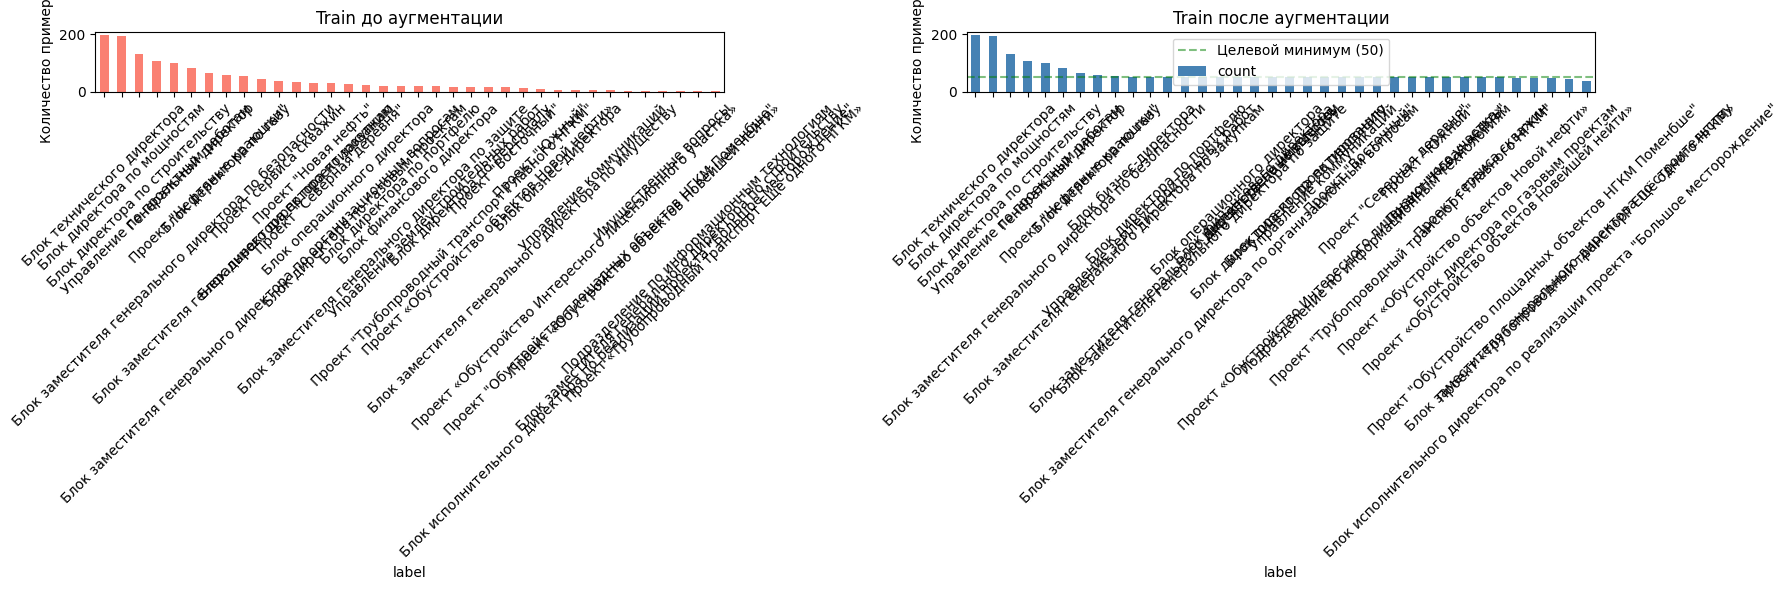

In [21]:
import matplotlib.pyplot as plt

# Сравниваем распределение: train до и после аугментации
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dist_train.plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("Train до аугментации")
axes[0].set_ylabel("Количество примеров")
axes[0].tick_params(axis="x", rotation=45)

dist_final.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Train после аугментации")
axes[1].set_ylabel("Количество примеров")
axes[1].axhline(y=50, color="g", linestyle="--", alpha=0.5, label="Целевой минимум (50)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

___
## Классификация — оценка качества аугментации

Обучаем на аугментированном train, оцениваем на отложенном test.
Данные загружаются один раз, все модели используют одни и те же эмбеддинги.

### Загрузка данных и эмбеддингов

In [19]:
from src.classification.evaluate import load_data, evaluate_model

X_train, y_train, X_test, y_test, label_names = load_data()

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Классов: {len(label_names)}")

[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2316 записей)
[Данные] Тестовая выборка: data_test.csv (341 записей)
[TF-IDF] Параметры: max_features=50000, ngram_range=(1, 2)
[TF-IDF] Обучаю на 2316 текстах...
[TF-IDF] Готово: train (2316, 43510), test (341, 43510)
[TF-IDF] Кэш сохранён (ключ: b89ca392d7f7)
Train: (2316, 43510), Test: (341, 43510), Классов: 36


### Linear SVM

In [27]:
from sklearn.svm import LinearSVC

augmented_results = []

augmented_results.append(evaluate_model(
    name="[Augmented] Linear SVM",
    estimator=LinearSVC(max_iter=10000, random_state=RANDOM_SEED, dual="auto"),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

КЛАССИФИКАЦИЯ: [Augmented] Linear SVM
[[Augmented] Linear SVM] Train: 2316, Test: 341, Классов: 36
[[Augmented] Linear SVM] Лучшие параметры: {'C': 10} (CV macro F1 = 0.8309)

[[Augmented] Linear SVM] Результаты на тестовой выборке:
  Balanced Accuracy: 0.5183
  Macro F1:          0.5066

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.62      0.57      0.59        14
                                          Блок директора по газовым проектам       0.50      0.17      0.25         6
                                                 Блок директора по мощностям       0.75      0.94      0.83        48
                                                 Блок директора по персоналу       1.00      0.67      0.80         3
 

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

augmented_results.append(evaluate_model(
    name="[Augmented] Logistic Regression",
    estimator=LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

КЛАССИФИКАЦИЯ: [Augmented] Logistic Regression
[[Augmented] Logistic Regression] Train: 2335, Test: 341, Классов: 36
[[Augmented] Logistic Regression] Лучшие параметры: {'C': 10} (CV macro F1 = 0.7928)

[[Augmented] Logistic Regression] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4541
  Macro F1:          0.4616

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.80      0.29      0.42        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.71      0.94      0.81        48
                                                 Блок директора по персоналу       

### Multinomial Naive Bayes

In [24]:
from sklearn.naive_bayes import MultinomialNB

augmented_results.append(evaluate_model(
    name="[Augmented] Multinomial Naive Bayes",
    estimator=MultinomialNB(),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"alpha": [0.01, 0.1, 0.5, 1.0]},
))

КЛАССИФИКАЦИЯ: [Augmented] Multinomial Naive Bayes
[[Augmented] Multinomial Naive Bayes] Train: 2284, Test: 341, Классов: 36
[[Augmented] Multinomial Naive Bayes] Лучшие параметры: {'alpha': 0.01} (CV macro F1 = 0.8260)

[[Augmented] Multinomial Naive Bayes] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4775
  Macro F1:          0.4777

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.70      0.50      0.58        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.69      0.98      0.81        48
                                                 Блок директо

### BERT-модели (fine-tuning)


In [28]:
from src.classification.rubert_classifier import train_and_evaluate

# df_final уже загружен выше (stage=3), df_test_baseline тоже
for cfg in RUBERT_CONFIGS:
    augmented_results.append(train_and_evaluate(
        df_train=df_final,
        df_test=df_test_baseline,
        model_name=cfg["model_name"],
        lr=cfg["lr"],
        num_epochs=10,
        batch_size=cfg["batch_size"],
        name=f"[Augmented] {cfg['short_name']}",
    ))


[[Augmented] rubert-tiny2] Device: cuda, Model: cointegrated/rubert-tiny2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[[Augmented] rubert-tiny2] Train: 2316, Test: 341, Классов: 36, Эпох: 10


  Epoch 1/10 — loss: 3.3500


  Epoch 2/10 — loss: 2.1664


...

  Epoch 6/10 — loss: 0.4079


  Epoch 7/10 — loss: 0.2562


  Epoch 8/10 — loss: 0.1562


  Epoch 9/10 — loss: 0.1076


  Epoch 10/10 — loss: 0.0753

[[Augmented] rubert-base] Результаты на тестовой выборке:
  Balanced Accuracy: 0.5349
  Macro F1:          0.4718

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.60      0.43      0.50        14
                                          Блок директора по газовым проектам       0.50      0.17      0.25         6
                                                 Блок директора по мощностям       0.78      0.79      0.78        48
                                                 Блок директора по персоналу       0.43      1.00      0.60         3
                                                  Блок директора по портфелю       0.00      0.00      0.00         4
                            

___
## Сравнение: Baseline vs Augmented

Сводная таблица и график — как изменились метрики после аугментации для каждого классификатора.

Модель                    | Метрика              |   Baseline |  Augmented |      Delta
-----------------------------------------------------------------------------------
  Linear SVM              | Balanced Accuracy    |     0.4208 |     0.4820 | +   0.0612
  Linear SVM              | Macro F1             |     0.4434 |     0.4530 | +   0.0097
-----------------------------------------------------------------------------------
  Logistic Regression     | Balanced Accuracy    |     0.3089 |     0.4541 | +   0.1451
  Logistic Regression     | Macro F1             |     0.3350 |     0.4616 | +   0.1266
-----------------------------------------------------------------------------------
  Multinomial Naive Bayes | Balanced Accuracy    |     0.3849 |     0.4652 | +   0.0804
  Multinomial Naive Bayes | Macro F1             |     0.4026 |     0.4612 | +   0.0586
-----------------------------------------------------------------------------------
  rubert-tiny2            | Balanced Accuracy   

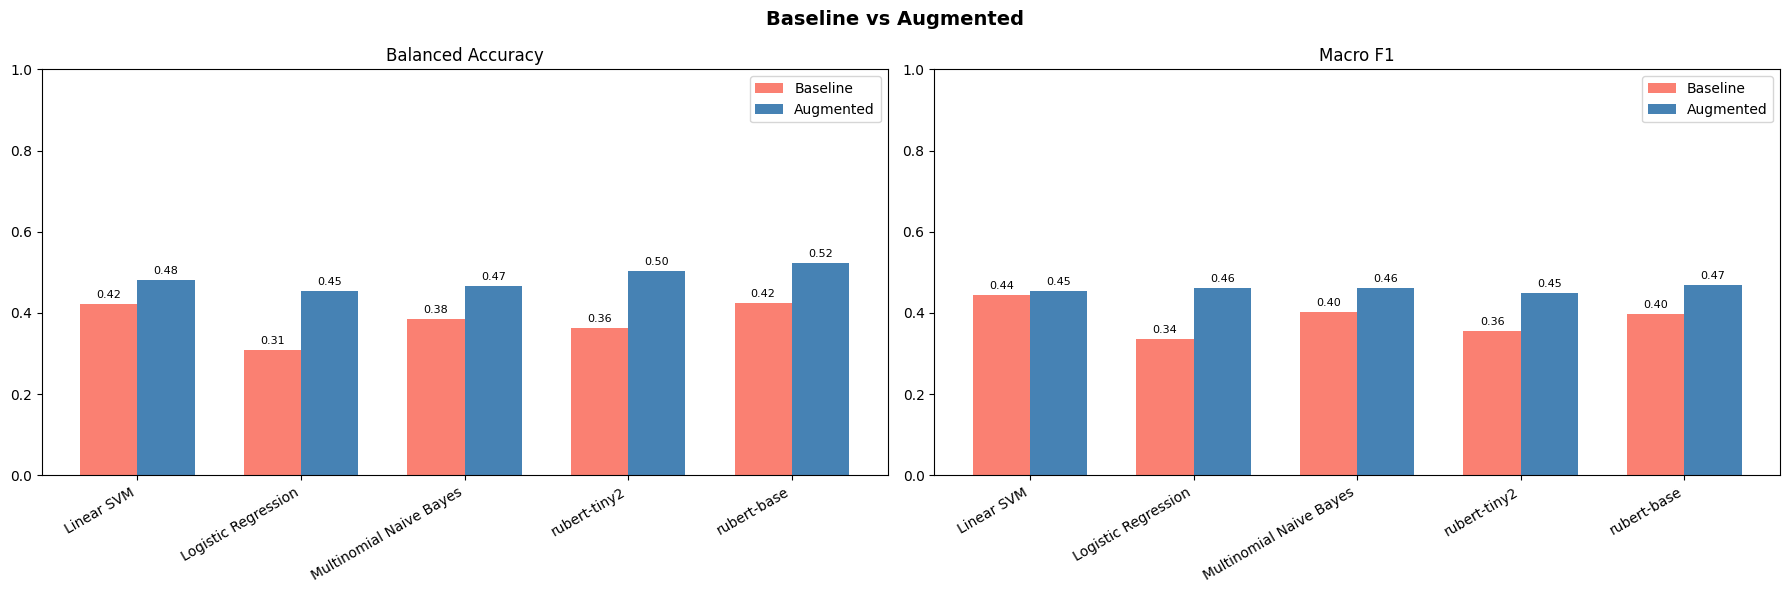

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Названия моделей (без префикса [Baseline]/[Augmented])
model_names = [r["name"].split("] ")[1] for r in baseline_results]

metrics = ["balanced_accuracy", "macro_f1"]
metric_labels = ["Balanced Accuracy", "Macro F1"]

# Таблица
rows = []
print(f"{'Модель':<25} | {'Метрика':<20} | {'Baseline':>10} | {'Augmented':>10} | {'Delta':>10}")
print("-" * 83)
for i, name in enumerate(model_names):
    for m, ml in zip(metrics, metric_labels):
        b = baseline_results[i][m]
        a = augmented_results[i][m]
        delta = a - b
        sign = "+" if delta >= 0 else ""
        print(f"  {name:<23} | {ml:<20} | {b:>10.4f} | {a:>10.4f} | {sign}{delta:>9.4f}")
    print("-" * 83)
    rows.append({
        "stage": "baseline",
        "model": name,
        "balanced_accuracy": round(float(baseline_results[i]["balanced_accuracy"]), 4),
        "macro_f1": round(float(baseline_results[i]["macro_f1"]), 4),
    })
    rows.append({
        "stage": "augmented",
        "model": name,
        "balanced_accuracy": round(float(augmented_results[i]["balanced_accuracy"]), 4),
        "macro_f1": round(float(augmented_results[i]["macro_f1"]), 4),
    })

# График
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(model_names))
width = 0.35

for ax, m, ml in zip(axes, metrics, metric_labels):
    vals_b = [r[m] for r in baseline_results]
    vals_a = [r[m] for r in augmented_results]

    bars_b = ax.bar(x - width/2, vals_b, width, label="Baseline", color="salmon")
    bars_a = ax.bar(x + width/2, vals_a, width, label="Augmented", color="steelblue")

    ax.set_title(ml)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.legend()

    # Подписи значений
    for bar in bars_b:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars_a:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Baseline vs Augmented", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


results_dir = Path("/content/drive/MyDrive/VKR/code/results")
results_dir.mkdir(exist_ok=True)
pd.DataFrame(rows).to_csv(results_dir / "classification_results.csv", index=False)
print(f"\nСохранено: {results_dir / 'classification_results.csv'}")


In [ ]:
import pandas as pd
from pathlib import Path

# --- Сводим baseline и augmented результаты в один CSV ---
results_dir = Path(f"{PROJECT_ROOT}/results")
results_dir.mkdir(exist_ok=True)

rows = []
for r in baseline_results:
    rows.append({
        "stage": "baseline",
        "model": r["name"].replace("[Baseline] ", "").replace("[Augmented] ", ""),
        "balanced_accuracy": round(r["balanced_accuracy"], 4),
        "macro_f1": round(r["macro_f1"], 4),
    })
for r in augmented_results:
    rows.append({
        "stage": "augmented",
        "model": r["name"].replace("[Baseline] ", "").replace("[Augmented] ", ""),
        "balanced_accuracy": round(r["balanced_accuracy"], 4),
        "macro_f1": round(r["macro_f1"], 4),
    })

df_results = pd.DataFrame(rows)
csv_path = results_dir / "classification_results.csv"
df_results.to_csv(csv_path, index=False)
print(f"Сохранено: {csv_path}")
print()
print(df_results.to_string(index=False))


Сохранено: /Users/kvt/Documents/VKR/code/results/classification_results.csv

    stage                   model  balanced_accuracy  macro_f1
 baseline              Linear SVM             0.4820    0.4530
 baseline     Logistic Regression             0.4541    0.4616
 baseline Multinomial Naive Bayes             0.4652    0.4612
 baseline            rubert-tiny2             0.5027    0.4497
 baseline             rubert-base             0.5221    0.4696
augmented              Linear SVM             0.4820    0.4530
augmented     Logistic Regression             0.4541    0.4616
augmented Multinomial Naive Bayes             0.4652    0.4612
augmented            rubert-tiny2             0.5027    0.4497
augmented             rubert-base             0.5221    0.4696
